# Data Preprocessing & Feature Engineering — Practice Notebook
## Topic: Missing Values, Outliers & Encoding

Welcome! This notebook gives you hands-on practice with the three core
cleaning skills:

1. **Handling missing values** (imputation)
2. **Detecting & removing outliers** (IQR method)
3. **Encoding categorical variables** (Label & One-Hot)

## Step 0 — Setup & the messy dataset *(provided — just run this cell)*

We work with a small employee dataset (20 rows) that was deliberately built
to contain every problem we study: missing values, an impossible age (150),
a huge salary outlier (9,999,999), an ordinal column (Education) and several
nominal columns (Gender, Department, City).

In [2]:
import pandas as pd
import numpy as np

data = {
    'EmployeeID': list(range(1, 21)),
    'Age':        [25,30,np.nan,35,28,150,40,33,29,45,38,26,50,31,27,np.nan,42,36,34,39],
    'Gender':     ['Male','Female','Male','Female','Male','Female',np.nan,'Male','Female','Male',
                   'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male'],
    'Department': ['Sales','IT','HR','Finance','IT','Sales','HR','Finance','IT','Sales',
                   np.nan,'IT','Finance','HR','Sales','IT','Finance','Sales','HR','IT'],
    'Education':  ['Bachelor','Master','Bachelor','PhD','Bachelor','High School','Master','Bachelor',
                   'Master','High School','PhD','Bachelor','Master','Bachelor','High School','Master',
                   'PhD','Bachelor','Master','Bachelor'],
    'Experience': [2,5,3,10,4,1,12,8,5,np.nan,15,3,20,np.nan,2,7,18,9,11,np.nan],
    'Salary':     [45000,60000,50000,90000,np.nan,35000,75000,65000,58000,48000,
                   95000,9999999,110000,np.nan,38000,70000,105000,62000,72000,68000],
    'City':       ['Mumbai','Delhi','Mumbai','Bangalore','Delhi','Pune','Mumbai','Bangalore','Delhi',
                   'Pune','Mumbai','Delhi','Bangalore','Pune','Mumbai','Delhi','Bangalore','Pune',
                   'Mumbai','Delhi'],
}
df = pd.DataFrame(data)
print("Shape:", df.shape)
df.head()

Shape: (20, 8)


,EmployeeID,Age,Gender,Department,Education,Experience,Salary,City
0,1,25.0,Male,Sales,Bachelor,2.0,45000.0,Mumbai
1,2,30.0,Female,IT,Master,5.0,60000.0,Delhi
2,3,NaN,Male,HR,Bachelor,3.0,50000.0,Mumbai
3,4,35.0,Female,Finance,PhD,10.0,90000.0,Bangalore
4,5,28.0,Male,IT,Bachelor,4.0,NaN,Delhi


# Part 1 — Handling Missing Values

### Q1. Inspect the data
Display the first 5 rows, then use `.info()` to see the column types and how many non-null values each column has.

In [3]:
df.head()

,EmployeeID,Age,Gender,Department,Education,Experience,Salary,City
0,1,25.0,Male,Sales,Bachelor,2.0,45000.0,Mumbai
1,2,30.0,Female,IT,Master,5.0,60000.0,Delhi
2,3,NaN,Male,HR,Bachelor,3.0,50000.0,Mumbai
3,4,35.0,Female,Finance,PhD,10.0,90000.0,Bangalore
4,5,28.0,Male,IT,Bachelor,4.0,NaN,Delhi


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  20 non-null     int64  
 1   Age         18 non-null     float64
 2   Gender      19 non-null     object 
 3   Department  19 non-null     object 
 4   Education   20 non-null     object 
 5   Experience  17 non-null     float64
 6   Salary      18 non-null     float64
 7   City        20 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 1.4+ KB


### Q2. Count missing values
Count how many values are missing in **each** column.

In [5]:
df.isnull().sum()

EmployeeID    0
Age           2
Gender        1
Department    1
Education     0
Experience    3
Salary        2
City          0
dtype: int64

### Q3. Percentage missing
Show the **percentage** of values missing in each column, rounded to 1 decimal place.

In [7]:
(df.isnull().mean() * 100).round(1)

EmployeeID     0.0
Age           10.0
Gender         5.0
Department     5.0
Education      0.0
Experience    15.0
Salary        10.0
City           0.0
dtype: float64

### Q4. Which column has the most missing values?
Answer in the markdown cell, then prove it with one line of code.

Column "Experience" has the most Missing Values

In [9]:
df.isnull().mean().max()

0.15

### Q5. Impute `Age` with the median
Fill the missing ages with the column **median** (median is safer than mean because Age has the outlier 150).

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [11]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        1
Department    1
Education     0
Experience    3
Salary        2
City          0
dtype: int64

### Q6. Impute `Experience` with the median

In [12]:
df["Experience"] = df["Experience"].fillna(df["Experience"].median())

In [13]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        1
Department    1
Education     0
Experience    0
Salary        2
City          0
dtype: int64

### Q7. Impute `Salary` with the median

In [14]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [15]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        1
Department    1
Education     0
Experience    0
Salary        0
City          0
dtype: int64

### Q8. Impute `Gender` with the mode
`Gender` is categorical (text), so fill it with the **most frequent** value.

In [16]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [20]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        0
Department    0
Education     0
Experience    0
Salary        0
City          0
dtype: int64

### Q9. Impute `Department` with the mode

In [21]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

In [22]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        0
Department    0
Education     0
Experience    0
Salary        0
City          0
dtype: int64

### Q10. Verify no missing values remain
Confirm the total number of missing values across the whole DataFrame is now **0**.

In [23]:
print(df.isnull().sum().sum())

0


# Part 2 — Detecting & Removing Outliers (IQR)

### Q11. Quartiles & IQR for `Age`
Compute `Q1` (25th percentile), `Q3` (75th percentile) and `IQR = Q3 - Q1` for the `Age` column. Print all three.

In [27]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

29.75
39.25
9.5


### Q12. Lower & upper bounds for `Age`
Using the IQR rule, compute the lower and upper 'fences':

$$\text{lower}=Q1-1.5\times IQR \qquad \text{upper}=Q3+1.5\times IQR$$

In [31]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(lower_fence)
print(upper_fence)

15.5
53.5


### Q13. Find the outlier rows in `Age`
Show the rows where `Age` is below the lower bound or above the upper bound.

In [32]:
outliers = df[(df["Age"] < lower_fence) | (df["Age"] > upper_fence)] ## to see outliers

In [33]:
print(outliers)

   EmployeeID    Age  Gender Department    Education  Experience   Salary  \
5           6  150.0  Female      Sales  High School         1.0  35000.0   

   City  
5  Pune  


### Q14. Repeat for `Salary`
Compute Q1, Q3, IQR, the bounds, and show the outlier rows for the `Salary` column.

In [34]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(lower_fence)
print(upper_fence)

21875.0
112875.0


In [36]:
outliers = df[(df["Salary"] < lower_fence) | (df["Salary"] > upper_fence)]
print(outliers)

    EmployeeID   Age Gender Department Education  Experience     Salary   City
11          12  26.0   Male         IT  Bachelor         3.0  9999999.0  Delhi


### Q15. Remove the outliers
Keep only the rows where **both** `Age` and `Salary` fall inside their IQR bounds. Print the shape before and after.

In [37]:
print(df.shape)

# For age
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# For salary
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

#Keep rows between age and salary
def_both = df[
(df["Age"].between(lower_fence, upper_fence)) & (df["Salary"].between(lower_fence, upper_fence))
]

print(def_both.shape)



(20, 8)
(0, 8)


### Q16. *(Optional)* Visualise with a box plot
Draw a box plot of `Age` to see that the extreme value is gone. (Requires `matplotlib`.)

In [38]:
import matplotlib.pyplot as plt

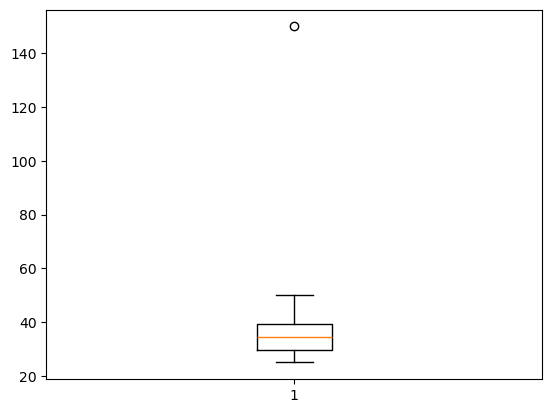

In [39]:
plt.boxplot(df["Age"])
plt.show()

# Part 3 — Encoding Categorical Variables

### Q17. Label-encode `Education` (ordinal)
`Education` has a natural order: High School < Bachelor < Master < PhD. Create a new column `Education_Label` mapping these to 0, 1, 2, 3.

In [43]:
edu_order = {"High School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df["Education-label"] = df["Education"].map(edu_order)

print(df[['Education', 'Education_Label']])

      Education  Education_Label
0      Bachelor                1
1        Master                2
2      Bachelor                1
3           PhD                3
4      Bachelor                1
5   High School                0
6        Master                2
7      Bachelor                1
8        Master                2
9   High School                0
10          PhD                3
11     Bachelor                1
12       Master                2
13     Bachelor                1
14  High School                0
15       Master                2
16          PhD                3
17     Bachelor                1
18       Master                2
19     Bachelor                1


### Q18. Encode `Gender` as 0/1
`Gender` has only two values, so map Male -> 0 and Female -> 1 into a new column `Gender_Label`.

In [44]:
gender = {"Male": 0, "Female": 1}
df["Gender_label"] = df["Gender"].map(gender)

print(df[["Gender_label", "Gender"]])

    Gender_label  Gender
0              0    Male
1              1  Female
2              0    Male
3              1  Female
4              0    Male
5              1  Female
6              0    Male
7              0    Male
8              1  Female
9              0    Male
10             1  Female
11             0    Male
12             1  Female
13             0    Male
14             1  Female
15             0    Male
16             1  Female
17             0    Male
18             1  Female
19             0    Male


### Q19. One-hot encode `Department` and `City`
These are **nominal** (no order), so use one-hot encoding. Use `pd.get_dummies` with prefixes `Dept` and `City`.

In [45]:
df = pd.get_dummies(df, columns = ["Department", "City"], drop_first = False)

In [48]:
df.head()

,EmployeeID,Age,Gender,Education,Experience,Salary,Education_Label,Education-label,Gender_label,Department_Finance,Department_HR,Department_IT,Department_Sales,City_Bangalore,City_Delhi,City_Mumbai,City_Pune
0,1,25.0,Male,Bachelor,2.0,45000.0,1,1,0,False,False,False,True,False,False,True,False
1,2,30.0,Female,Master,5.0,60000.0,2,2,1,False,False,True,False,False,True,False,False
2,3,34.5,Male,Bachelor,3.0,50000.0,1,1,0,False,True,False,False,False,False,True,False
3,4,35.0,Female,PhD,10.0,90000.0,3,3,1,True,False,False,False,True,False,False,False
4,5,28.0,Male,Bachelor,4.0,66500.0,1,1,0,False,False,True,False,False,True,False,False


### Q20. Inspect the final dataset
Print the final shape and the list of columns. Confirm there are no missing values.

In [47]:
df.shape
df.columns.tolist()
df.isnull().sum()

EmployeeID            0
Age                   0
Gender                0
Education             0
Experience            0
Salary                0
Education_Label       0
Education-label       0
Gender_label          0
Department_Finance    0
Department_HR         0
Department_IT         0
Department_Sales      0
City_Bangalore        0
City_Delhi            0
City_Mumbai           0
City_Pune             0
dtype: int64

# Bonus Challenge

### Q21. Write a single `preprocess(df)` function
Combine everything into one reusable function that takes a raw DataFrame and returns the cleaned, encoded version. Test it by re-creating the raw data and passing it in.

In [51]:
import pandas as pd
import numpy as np

def preprocess(df):
 
    df = df.copy()

    # 1. Handle Missing Values
    for col in ['Age', 'Experience', 'Salary']:
        df[col] = df[col].fillna(df[col].median())

    for col in ['Gender', 'Department']:
        df[col] = df[col].fillna(df[col].mode()[0])


    # 2. Remove Outliers (IQR)
    mask = pd.Series(True, index=df.index)

    for col in ['Age', 'Salary']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask &= df[col].between(lower, upper)

    df = df[mask].reset_index(drop=True)

 
    # 3. Label Encoding
    edu_order = {
        'High School': 0,
        'Bachelor': 1,
        'Master': 2,
        'PhD': 3
    }

    df['Education_Label'] = df['Education'].map(edu_order)

    df['Gender_Label'] = df['Gender'].map({
        'Male': 0,
        'Female': 1
    })


    # 4. One-Hot Encoding
    df = pd.get_dummies(
        df,
        columns=['Department', 'City'],
        prefix=['Dept', 'City']
    )


    # 5. Convert True/False to 0/1
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df

In [56]:
# Re-create the raw dataset
df_raw = pd.DataFrame(data)

# Apply preprocessing
df_clean = preprocess(df_raw)

# Display results
df_clean.shape
df_clean.columns.tolist()
df_clean.isnull().sum().sum()
df_clean.head()

,EmployeeID,Age,Gender,Education,Experience,Salary,Education_Label,Gender_Label,Dept_Finance,Dept_HR,Dept_IT,Dept_Sales,City_Bangalore,City_Delhi,City_Mumbai,City_Pune
0,1,25.0,Male,Bachelor,2.0,45000.0,1,0,0,0,0,1,0,0,1,0
1,2,30.0,Female,Master,5.0,60000.0,2,1,0,0,1,0,0,1,0,0
2,3,34.5,Male,Bachelor,3.0,50000.0,1,0,0,1,0,0,0,0,1,0
3,4,35.0,Female,PhD,10.0,90000.0,3,1,1,0,0,0,1,0,0,0
4,5,28.0,Male,Bachelor,4.0,66500.0,1,0,0,0,1,0,0,1,0,0
